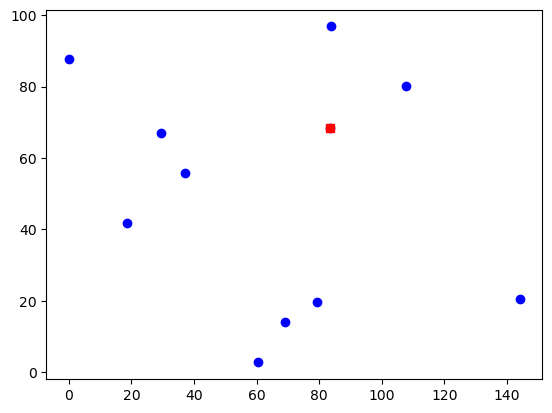

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gurobipy import *

rnd = np.random
rnd.seed(1) # 随机种子，如有本行，则程序每次运行结果一样。可任意赋值

n = 10 # 一共几个客户点/城市/需求点
xc = rnd.rand(n+1)*200 # 随机生成每个城市的横坐标，范围[0,200]
yc = rnd.rand(n+1)*100 # 随机生成每个城市的纵坐标，范围[0,100]

# 可以画图看一眼生成的城市什么样子
plt.plot(xc[0], yc[0], c='r',marker='s' ) # 索引为0的点，即depot/仓库/出发点
plt.scatter(xc, yc, c='b') # 客户点

In [2]:
N = list(range(1,n+1)) # 客户点集合
V = list(range(0,n+1)) # 所有点集合（仓库+客户点）
A = [(i,j) for i in V for j in V if i !=j] # 城市之间有哪些连线/路段/弧段
C = {(i,j): np.hypot(xc[i]-xc[j], yc[i]-yc[j]) for i,j in A} # np.hypot：二范数=求平方和；计算弧段的长度
Q = 20 # 车最大载重
q = {i:rnd.randint(1,10) for i in N} # 随机生成客户点的需求量，范围[1,10]

In [4]:
mdl = Model('CVRP') # 起名字

x = mdl.addVars(A, vtype=GRB.BINARY) # 增加变量xij，表示是否链接ij
u = mdl.addVars(N, vtype=GRB.CONTINUOUS) # 增加变量ui，表示车在该点处累计载货量

mdl.modelSense = GRB.MINIMIZE # 目标为最小化
mdl.setObjective(quicksum(x[i,j]*C[i,j] for i,j in A )) # 目标函数为总距离

# 添加所有约束
mdl.addConstrs(quicksum(x[i,j] for j in V if i != j)==1 for i in N) 
mdl.addConstrs(quicksum(x[i,j] for i in V if i!=j)==1 for j in N)
mdl.addConstrs((x[i,j]==1) >> 
               (u[i] + q[j] == u[j]) for i,j in A if i!=0 and j!=0)
mdl.addConstrs(u[i] >= q[i] for i in N)
mdl.addConstrs(u[i] <= Q for i in N)
mdl.setParam('LogToConsole', 1)  # 启用控制台日志
mdl.setParam('OutputFlag', 1)     # 启用输出标志

mdl.optimize() # 优化

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 20.04.6 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i7-13700KF, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2599216 - for non-commercial use only - registered to ni___@i2r.a-star.edu.sg
Optimize a model with 40 rows, 120 columns and 220 nonzeros
Model fingerprint: 0x3f2d4a4d
Model has 90 general constraints
Variable types: 10 continuous, 110 integer (110 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 2e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+01]
  GenCon rhs range [1e+00, 9e+00]
  GenCon coe range [1e+00, 1e+00]
Presolve added 142 rows and 3 columns
Presolve time: 0.01s
Presolved: 182 rows, 123 columns, 713 nonzeros
Variable types: 33 continuous, 90 integer (90 binary)
Found heuristic solution: objective 1018.8380700

Root relaxation: objective 3.638901e+02, 43 it

H  906   346                     614.1606157  475.51280  22.6%  12.7    0s
H  932   345                     611.6880568  476.07968  22.2%  12.6    0s

Cutting planes:
  Learned: 1

Explored 4525 nodes (54829 simplex iterations) in 1.17 seconds (1.04 work units)
Thread count was 2 (of 2 available processors)

Solution count 10: 611.688 614.161 620.214 ... 1018.84

Optimal solution found (tolerance 1.00e-04)
Best objective 6.116880568072e+02, best bound 6.116880568072e+02, gap 0.0000%


[(0, 4), (0, 6), (0, 10), (1, 0), (2, 0), (3, 7), (4, 3), (5, 2), (6, 5), (7, 8), (8, 0), (9, 1), (10, 9)]


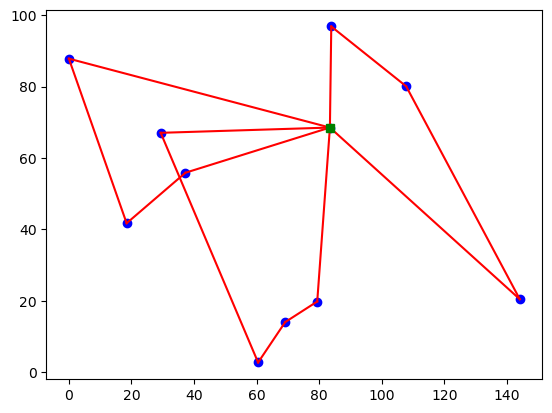

In [4]:
#优化完成，下面输出结果
active_arts = [a for a in A if x[a].x > 0.9] # 输出最优解的所有连线，即xij中是1的(i,j)
# 由于存在误差，xij可能为0.999999999，因此不要用==1
print(active_arts)

# 画图
for index, (i,j) in enumerate(active_arts):
    plt.plot([xc[i],xc[j]],[yc[i],yc[j]],c='r')
plt.plot(xc[0], yc[0], c='g',marker='s' )
plt.scatter(xc, yc, c='b')